In [3]:
import subprocess
def create_chunks(file, out, n):
    with open(file, 'r') as f_in, open(out, 'w') as f_out:
        for line in f_in:
            seq = line.strip()
            for i in range(len(seq) - n + 1):
                f_out.write(seq[i:i+n] + "\n")

def pipeline(test, n, r):
    chunk_train = f"eng_mod_n_{n}_r_{r}.train"
    create_chunks("eng_mod.train", chunk_train, n)
    cmd = [
        "java", "-jar", "negsel2.jar",
        "-self", f"{chunk_train}", 
        "-n", str(n), 
        "-r", str(r), 
        "-c", "-l"
    ]
    results = []
    with open(test, 'r') as f:
        for line in f:
            seq = line.strip()
            chunks = [seq[i:i+n] for i in range(len(seq) - n + 1)]
            result = subprocess.run(cmd, input="\n".join(chunks), capture_output=True, text=True)
            scores = [float(s) for s in result.stdout.splitlines() if s.strip()]
            avg_score = sum(scores) / len(scores) if scores else 0.0
            results.append(avg_score)
    return results

In [ ]:
# adjust the training and testing data for english
import random

in_train = "english.train"
out_train = "eng_mod.train"

with open(in_train, 'r') as f_in, open(out_train, 'w') as f_out:
    for line in f_in:
        text = line.strip()
        repeat = random.randint(1, 10)
        new = text * repeat
        f_out.write(new + '\n')

in_test = "english.test"
out_test = "eng_mod.test"

with open(in_test, 'r') as f_in, open(out_test, 'w') as f_out:
    for line in f_in:
        text = line.strip()
        repeat = random.randint(1, 10)
        new = text * repeat
        f_out.write(new + '\n')

in_test = "tagalog.test"
out_test = "tag_mod.test"

with open(in_test, 'r') as f_in, open(out_test, 'w') as f_out:
    for line in f_in:
        text = line.strip()
        repeat = random.randint(1, 10)
        new = text * repeat
        f_out.write(new + '\n')

In [9]:
results_2 = {}
n = 10

for r in range(4, 8):
    print(f"Processing r={r}")
    english = pipeline("eng_mod.test", n, r)
    tagalog = pipeline("tag_mod.test", n, r)
    y_true = [0] * len(english) + [1] * len(tagalog)
    y_scores = english + tagalog
    results_2[r] = {"y_true": y_true, "y_scores": y_scores}

Processing r=4
Processing r=5
Processing r=6
Processing r=7


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

r=1 | AUC: 0.5000
r=2 | AUC: 0.6559
r=3 | AUC: 0.8675


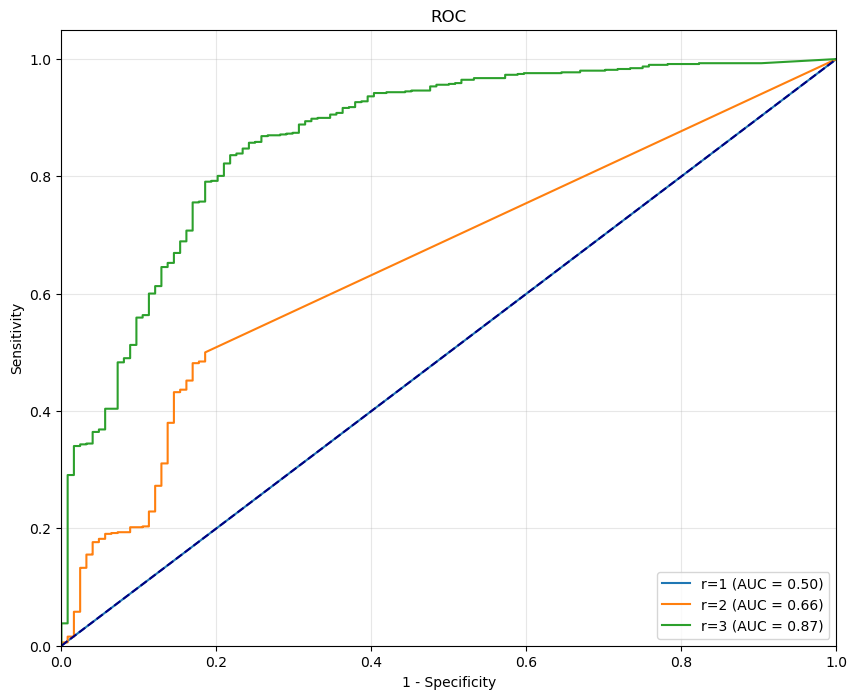

In [8]:
plt.figure(figsize=(10, 8))

for r, data in results.items():
    x, y, _ = roc_curve(data["y_true"], data["y_scores"])
    auc_score = auc(x, y)
    print(f"r={r} | AUC: {auc_score:.4f}")
    plt.plot(x, y, label=f'r={r} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

r=4 | AUC: 0.8937
r=5 | AUC: 0.8873
r=6 | AUC: 0.8838
r=7 | AUC: 0.8555


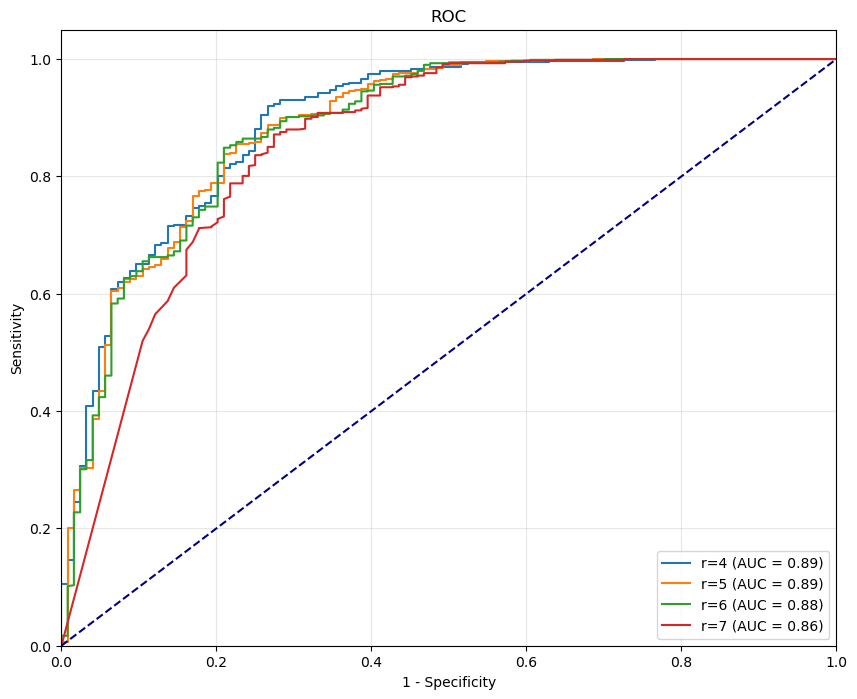

In [10]:
plt.figure(figsize=(10, 8))

for r, data in results_2.items():
    x, y, _ = roc_curve(data["y_true"], data["y_scores"])
    auc_score = auc(x, y)
    print(f"r={r} | AUC: {auc_score:.4f}")
    plt.plot(x, y, label=f'r={r} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()